#  CHALLENGE DATA 

**Cours : Machine Learning — Projet Data | IFIE2 Données**  
**Auteur : Fresnel KENGNE - Carlos SIBEFEU**



## Maladie de Parkinson : Prédire et Corriger les Biais dans l'Évaluation du Score Moteur par Institut du Cerveau

## 0. Imports et chargement des données

In [1]:
#! pip install xgboost

import numpy as np
import pandas as pd

# pour réaliser des visualisations
import matplotlib.pyplot as plt
import seaborn as sns


# geographiques
#from shapely.geometry import Point
#import geopandas as gpd
#from geopandas import GeoDataFrame
#import geoplot

# pour pré-traiter les données
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import Ridge
from sklearn.preprocessing import OneHotEncoder



from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
import xgboost as xgb


In [77]:
# Chargement du jeu de données

X_train = pd.read_csv("données/X_train_6ZIKlTY.csv")
y_train = pd.read_csv("données/y_train_lXj6X5y.csv")
X_test = pd.read_csv("données/X_test_oiZ2ukx.csv")

In [78]:
X_train.head()

,Index,patient_id,cohort,sexM,gene,age_at_diagnosis,age,ledd,time_since_intake_on,time_since_intake_off,on,off
0,0,IPLP5212,A,0,LRRK2+,48.5,52.1,607.0,1.9,NaN,7.0,NaN
1,1,IPLP5212,A,0,LRRK2+,48.5,53.0,666.0,1.9,17.6,12.0,44.0
2,2,IPLP5212,A,0,LRRK2+,48.5,53.9,717.0,1.2,NaN,6.0,NaN
3,3,IPLP5212,A,0,LRRK2+,48.5,54.8,770.0,1.5,NaN,11.0,NaN
4,4,IPLP5212,A,0,LRRK2+,48.5,56.9,885.0,0.3,NaN,24.0,NaN


In [79]:
y_train.head()

,Index,target
0,0,34.7
1,1,38.1
2,2,41.6
3,3,44.9
4,4,52.0


In [80]:
X_test.head()

,Index,patient_id,cohort,sexM,gene,age_at_diagnosis,age,ledd,time_since_intake_on,time_since_intake_off,on,off,time_since_diagnosis
0,0,KQYS2327,A,1,NaN,43.8,48.5,791.0,1.7,NaN,25.0,NaN,4.7
1,1,KQYS2327,A,1,NaN,43.8,49.1,826.0,2.8,NaN,25.0,NaN,5.3
2,2,KQYS2327,A,1,NaN,43.8,49.5,848.0,0.7,13.8,33.0,41.0,5.7
3,3,KQYS2327,A,1,NaN,43.8,50.0,874.0,5.2,NaN,34.0,NaN,6.2
4,4,KQYS2327,A,1,NaN,43.8,50.8,924.0,3.4,13.7,30.0,47.0,7.0


### Explication des features

| Index                     | Description |
|---------------------------|-------------|
| Index                     | Index |
| patient_id                | ID Patient |
| cohort                    | ID Cohorte (groupe) |
| sexM                      | Genre |
| gene                      | Marqueurs génétiques |
| age_at_diagnosis          | Âge au moment du diagnostique |
| age                       | Âge |
| ledd                      | Posologie médicament lévodopa en dose quotidienne équivalente (LEDD) |
| time_since_intake_on      | Délai depuis dernière prise de médicament pour Score ON |
| time_since_intake_off     | Délai depuis dernière prise de médicament pour Score OFF |
| on                        | Score ON |
| off                       | Score OFF |
| time_since_diagnosis      | Temps écoulé depuis le diagnostic |

## 1. Exploration du Jeu de Données


In [81]:
# On vérifie la taille des dataset
X_train.shape, y_train.shape, X_test.shape

((55603, 12), (55603, 2), (23672, 13))

In [82]:
# Informations sur le dataset
X_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55603 entries, 0 to 55602
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Index                  55603 non-null  int64  
 1   patient_id             55603 non-null  object 
 2   cohort                 55603 non-null  object 
 3   sexM                   55603 non-null  int64  
 4   gene                   37645 non-null  object 
 5   age_at_diagnosis       52773 non-null  float64
 6   age                    55603 non-null  float64
 7   ledd                   35010 non-null  float64
 8   time_since_intake_on   29663 non-null  float64
 9   time_since_intake_off  11775 non-null  float64
 10  on                     38944 non-null  float64
 11  off                    32196 non-null  float64
dtypes: float64(7), int64(2), object(3)
memory usage: 5.1+ MB


In [83]:
# Pourcentage de valeurs nulles par colonnes
(X_train.isnull().mean() * 100).sort_values(ascending=False)

time_since_intake_off    78.823085
time_since_intake_on     46.652159
off                      42.096649
ledd                     37.035771
gene                     32.296819
on                       29.960614
age_at_diagnosis          5.089653
Index                     0.000000
patient_id                0.000000
cohort                    0.000000
sexM                      0.000000
age                       0.000000
dtype: float64

In [84]:
X_train["gene"].unique()

array(['LRRK2+', 'No Mutation', nan, 'GBA+', 'OTHER+'], dtype=object)

In [85]:
X_test["gene"].unique()

array([nan, 'No Mutation', 'LRRK2+', 'GBA+', 'OTHER+'], dtype=object)

In [86]:
(X_test.isnull().mean() * 100).sort_values(ascending=False)

time_since_intake_off    78.747043
time_since_intake_on     47.296384
off                      41.272389
ledd                     37.449307
gene                     32.794018
on                       30.686043
Index                     0.000000
patient_id                0.000000
cohort                    0.000000
sexM                      0.000000
age_at_diagnosis          0.000000
age                       0.000000
time_since_diagnosis      0.000000
dtype: float64

In [87]:
y_train.isnull().sum()

Index     0
target    0
dtype: int64

Notre dataset de variables cibles ne contient pas de valeurs nulles.

In [88]:
# Description des datasets
X_train.describe()

,Index,sexM,age_at_diagnosis,age,ledd,time_since_intake_on,time_since_intake_off,on,off
count,55603.000000,55603.000000,52773.000000,55603.000000,35010.000000,29663.000000,11775.000000,38944.000000,32196.000000
mean,27801.000000,0.596353,56.734648,62.516422,638.102228,1.953717,14.199448,21.985980,26.295316
std,16051.347846,0.490633,10.823093,11.484480,219.443182,1.168793,2.844782,10.371291,16.534567
min,0.000000,0.000000,16.500000,16.500000,50.000000,0.000000,6.900000,0.000000,0.000000
25%,13900.500000,0.000000,49.500000,54.900000,481.000000,1.100000,12.200000,14.000000,13.000000
50%,27801.000000,1.000000,56.900000,62.500000,611.000000,1.600000,13.800000,21.000000,24.000000
75%,41701.500000,1.000000,64.400000,70.500000,765.000000,2.600000,15.700000,28.000000,38.000000
max,55602.000000,1.000000,89.900000,103.300000,1796.000000,6.300000,25.100000,95.000000,106.000000


In [89]:
X_test.describe()

,Index,sexM,age_at_diagnosis,age,ledd,time_since_intake_on,time_since_intake_off,on,off,time_since_diagnosis
count,23672.000000,23672.000000,23672.000000,23672.000000,14807.000000,12476.000000,5031.000000,16408.000000,13902.000000,23672.000000
mean,11835.500000,0.615960,56.393545,62.099159,637.611332,1.958216,14.135202,22.233057,26.316070,5.705615
std,6833.662122,0.486378,10.426912,11.333973,214.153023,1.172925,2.853948,10.736239,16.851214,4.455499
min,0.000000,0.000000,18.800000,19.100000,50.000000,0.000000,7.300000,0.000000,0.000000,-28.695144
25%,5917.750000,0.000000,49.600000,54.400000,486.000000,1.100000,12.200000,14.000000,13.000000,2.600000
50%,11835.500000,1.000000,56.295144,61.900000,616.000000,1.600000,13.800000,21.000000,24.000000,5.200000
75%,17753.250000,1.000000,63.600000,70.100000,764.500000,2.600000,15.600000,29.000000,37.750000,8.404856
max,23671.000000,1.000000,83.200000,100.600000,1562.000000,6.400000,25.000000,93.000000,108.000000,33.204856


In [90]:
X_train["time_since_diagnosis"] = X_train["age"] - X_train["age_at_diagnosis"]

In [91]:
y_train.describe()

,Index,target
count,55603.000000,55603.000000
mean,27801.000000,37.331606
std,16051.347846,16.504326
min,0.000000,0.000000
25%,13900.500000,25.400000
50%,27801.000000,37.100000
75%,41701.500000,49.200000
max,55602.000000,109.500000


Au vu de tout ce traitement, on pourrait : 
- Effacer les données manquantes
- Les remplacer par la médiane
- Effacer les colonnes qui semblent nous servir à rien: index, patientid, cohort, age(car on a deja l'ae de diagnostic et la durée entre cette date et la prise de l'enregistrement)
- Effacer le sexe puis travailler avec


In [92]:
#Concatenation de X_train et y_train
df = pd.concat([X_train, y_train], axis=1)
df.shape

(55603, 15)

In [93]:
#Suppression des colonnes inutiles
X_test = X_test.drop(columns=["Index","age","sexM"])
df = df.drop(columns=["Index","age","sexM"])
df.shape

(55603, 10)

In [94]:
df.head()

,patient_id,gene,age_at_diagnosis,ledd,time_since_intake_on,time_since_intake_off,on,off,time_since_diagnosis,target
0,IPLP5212,LRRK2+,48.5,607.0,1.9,NaN,7.0,NaN,3.6,34.7
1,IPLP5212,LRRK2+,48.5,666.0,1.9,17.6,12.0,44.0,4.5,38.1
2,IPLP5212,LRRK2+,48.5,717.0,1.2,NaN,6.0,NaN,5.4,41.6
3,IPLP5212,LRRK2+,48.5,770.0,1.5,NaN,11.0,NaN,6.3,44.9
4,IPLP5212,LRRK2+,48.5,885.0,0.3,NaN,24.0,NaN,8.4,52.0


In [95]:
#tableau de correlation des variables numeriques
dfNum = df.drop(columns=["cohort","gene","patient_id"])
dfNum.corr()

,age_at_diagnosis,ledd,time_since_intake_on,time_since_intake_off,on,off,time_since_diagnosis,target
age_at_diagnosis,1.000000,-0.160554,-0.004835,0.004601,0.038912,0.122826,0.000512,0.127892
ledd,-0.160554,1.000000,-0.001576,0.024608,0.211127,0.227920,0.714862,0.299595
time_since_intake_on,-0.004835,-0.001576,1.000000,0.006807,-0.220349,-0.008982,0.000713,0.002087
time_since_intake_off,0.004601,0.024608,0.006807,1.000000,0.002520,0.038192,0.017587,0.011191
on,0.038912,0.211127,-0.220349,0.002520,1.000000,0.867842,0.263368,0.687351
off,0.122826,0.227920,-0.008982,0.038192,0.867842,1.000000,0.425178,0.885098
time_since_diagnosis,0.000512,0.714862,0.000713,0.017587,0.263368,0.425178,1.000000,0.542539
target,0.127892,0.299595,0.002087,0.011191,0.687351,0.885098,0.542539,1.000000


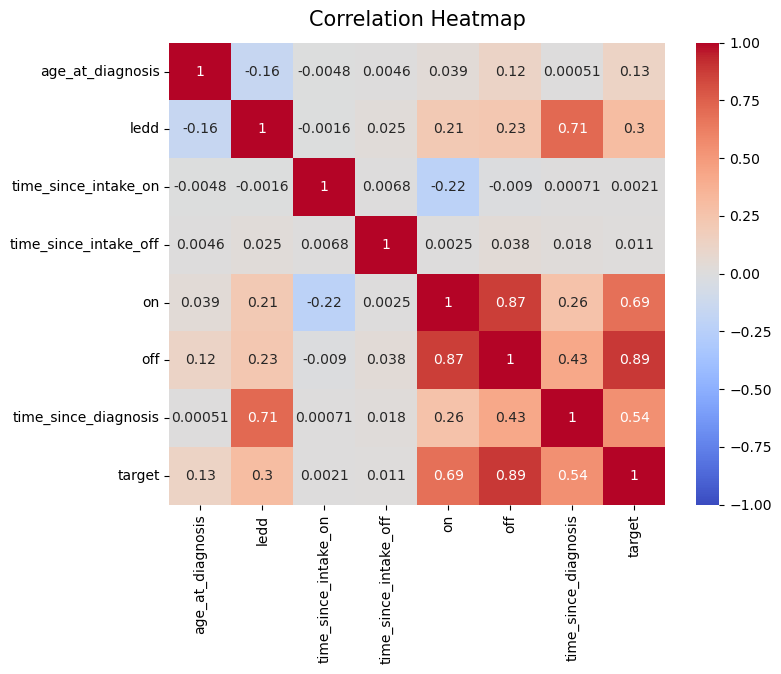

In [96]:
#Graphique visuelle du tableau de correlation
plt.figure(figsize=(8, 6))
heatmap = sns.heatmap(dfNum.corr(),cmap= "coolwarm" ,vmin=-1, vmax=1, annot=True)
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':15}, pad=12);

In [97]:
# Split en cours de telechargement

y = df["target"]
X = df.drop(columns=["target"])

# On sépare le jeu de données en jeu d'entraînement et en jeu de test
X_tr, X_ts, y_tr, y_ts = train_test_split(X, y, test_size=0.2, random_state=42)
# On vérifie la taille de chacun des jeux = leur somme doit être égale au jeu de départ

X_tr.shape, X_ts.shape,y_tr.shape,y_ts.shape

((44482, 9), (11121, 9), (44482,), (11121,))

## 2. Feature engineering 



In [98]:
##Gestion des valeurs manquantes (Mediane)

#valeurs numeriques
num_cols = X_tr.select_dtypes(include=np.number).columns

for col in num_cols:
    X_tr[col] = X_tr[col].fillna(X_tr.groupby("patient_id")[col].transform("median"))
    X_ts[col] = X_ts[col].fillna(X_ts.groupby("patient_id")[col].transform("median"))
    X_test[col] = X_test[col].fillna(X_test.groupby("patient_id")[col].transform("median"))
    
cat_cols = X_tr.select_dtypes(exclude=np.number).columns

for col in cat_cols:
    X_tr[col] = X_tr[col].fillna(
        X_tr.groupby("patient_id")[col].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    )
    X_ts[col] = X_ts[col].fillna(
        X_ts.groupby("patient_id")[col].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    )
    X_test[col] = X_test[col].fillna(
        X_test.groupby("patient_id")[col].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    )

X_tr[num_cols] = X_tr[num_cols].fillna(X_tr[num_cols].median())
X_ts[num_cols] = X_ts[num_cols].fillna(X_ts[num_cols].median())
X_test[num_cols] = X_test[num_cols].fillna(X_test[num_cols].median())


X_tr.isna().sum()

patient_id                   0
gene                     14328
age_at_diagnosis             0
ledd                         0
time_since_intake_on         0
time_since_intake_off        0
on                           0
off                          0
time_since_diagnosis         0
dtype: int64

In [99]:
X_tr = X_tr.drop(columns=["patient_id"])
X_ts = X_ts.drop(columns=["patient_id"])
X_test = X_test.drop(columns=["patient_id"])


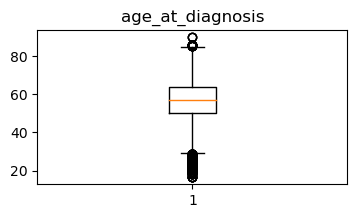

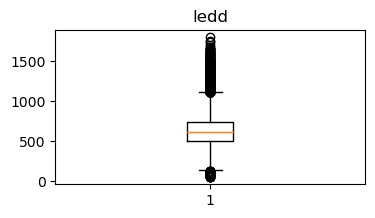

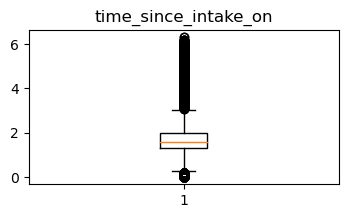

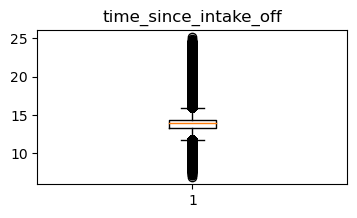

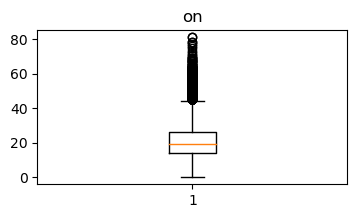

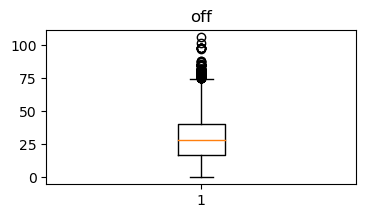

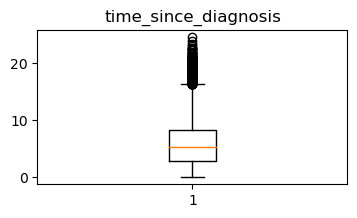

In [100]:
#Boxplot pour visualiser les valeurs aberrantes

num_cols = X_tr.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(4, 2))
    plt.boxplot(X_tr[col])
    plt.title(col)
    plt.show()

In [101]:
# Gestion des valeurs aberrantes (winsorization)
Q1 = X_tr[num_cols].quantile(0.25)
Q3 = X_tr[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Capping sur train et test avec les mêmes bornes
X_tr[num_cols] = X_tr[num_cols].clip(lower=lower, upper=upper, axis=1)
X_ts[num_cols] = X_ts[num_cols].clip(lower=lower, upper=upper, axis=1)
X_test[num_cols] = X_test[num_cols].clip(lower=lower, upper=upper, axis=1)

X_tr[num_cols].describe()

,age_at_diagnosis,ledd,time_since_intake_on,time_since_intake_off,on,off,time_since_diagnosis
count,44482.000000,44482.000000,44482.000000,44482.000000,44482.000000,44482.000000,44482.000000
mean,56.799278,632.803988,1.730608,13.906867,20.693033,29.021053,5.783994
std,10.428137,190.425642,0.676753,1.195357,9.086682,15.719710,3.732627
min,29.000000,136.500000,0.250000,11.775000,0.000000,0.000000,0.000000
25%,50.000000,501.000000,1.300000,13.350000,14.000000,17.000000,2.800000
50%,56.900000,615.000000,1.600000,13.900000,19.500000,28.000000,5.300000
75%,64.000000,744.000000,2.000000,14.400000,26.000000,40.000000,8.200000
max,85.000000,1108.500000,3.050000,15.975000,44.000000,74.500000,16.300000


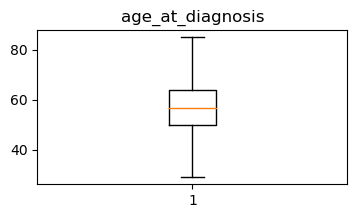

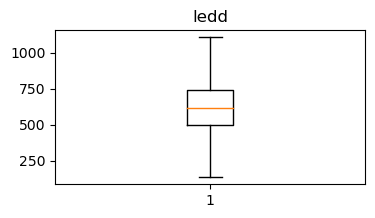

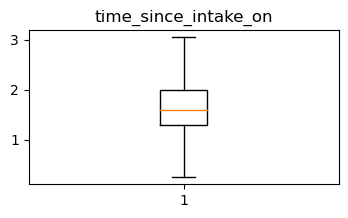

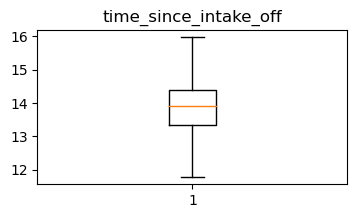

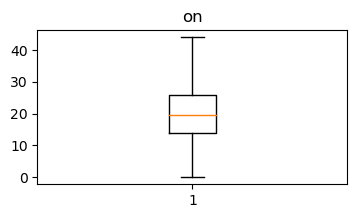

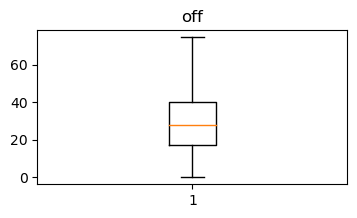

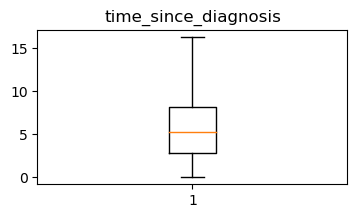

In [102]:
#verification
num_cols = X_tr.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(4, 2))
    plt.boxplot(X_tr[col])
    plt.title(col)
    plt.show()

In [103]:
##Gestion des variables categorielles

# Colonnes qui nous intéressent
cat_cols_shit = ["cohort","gene"]

# Initialisation de l'encoder
shit = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
shit.fit(X_tr[cat_cols_shit])

train_ohe = pd.DataFrame(
    shit.transform(X_tr[cat_cols_shit]),
    index=X_tr.index,
    columns=shit.get_feature_names_out(cat_cols_shit),
)

test_ohe = pd.DataFrame(
    shit.transform(X_ts[cat_cols_shit]),
    index=X_ts.index,
    columns=shit.get_feature_names_out(cat_cols_shit),
)
test_high = pd.DataFrame(
    shit.transform(X_test[cat_cols_shit]),
    index=X_test.index,
    columns=shit.get_feature_names_out(cat_cols_shit),
)

X_tr = X_tr.drop(columns=cat_cols_shit).join(train_ohe)
X_ts  = X_ts.drop(columns=cat_cols_shit).join(test_ohe)
X_test  = X_test.drop(columns=cat_cols_shit).join(test_high)

X_tr.shape, X_ts.shape

((44482, 12), (11121, 12))

In [104]:
X_tr.head()

,age_at_diagnosis,ledd,time_since_intake_on,time_since_intake_off,on,off,time_since_diagnosis,gene_GBA+,gene_LRRK2+,gene_No Mutation,gene_OTHER+,gene_nan
44464,69.2,609.0,2.2,14.7,20.0,22.0,3.6,0.0,0.0,0.0,0.0,1.0
38133,63.3,752.0,1.0,12.7,43.0,55.0,7.4,0.0,1.0,0.0,0.0,0.0
30901,56.8,810.0,1.0,13.8,39.0,43.0,9.2,0.0,1.0,0.0,0.0,0.0
53334,40.3,774.0,2.8,12.7,11.0,19.0,6.2,1.0,0.0,0.0,0.0,0.0
32070,65.2,434.0,1.5,13.9,13.0,28.0,2.8,0.0,0.0,0.0,0.0,1.0


In [105]:
#bien propre , bien soigné
X_tr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44482 entries, 44464 to 15795
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age_at_diagnosis       44482 non-null  float64
 1   ledd                   44482 non-null  float64
 2   time_since_intake_on   44482 non-null  float64
 3   time_since_intake_off  44482 non-null  float64
 4   on                     44482 non-null  float64
 5   off                    44482 non-null  float64
 6   time_since_diagnosis   44482 non-null  float64
 7   gene_GBA+              44482 non-null  float64
 8   gene_LRRK2+            44482 non-null  float64
 9   gene_No Mutation       44482 non-null  float64
 10  gene_OTHER+            44482 non-null  float64
 11  gene_nan               44482 non-null  float64
dtypes: float64(12)
memory usage: 5.4 MB


In [106]:
#Standardisation bien soigné
scaler = StandardScaler()

X_tr[num_cols] = scaler.fit_transform(X_tr[num_cols])
X_ts[num_cols] = scaler.transform(X_ts[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

---

## 3. Linear Regression & XGBOOST




In [107]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_tr, y_tr)
y_pred_lr = lr.predict(X_ts)
rmse_lr = root_mean_squared_error(y_ts, y_pred_lr)
print(f'Linear Regression RMSE : {rmse_lr:.4f}')

# XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators          = 1000,
    learning_rate         = 0.05,
    max_depth             = 6,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 5,
    gamma                 = 0.1,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    objective             = 'reg:squarederror',
    eval_metric           = 'rmse',
    early_stopping_rounds = 50,
    random_state          = 42,
    n_jobs                = -1,
)
xgb_model.fit(X_tr, y_tr, eval_set=[(X_ts, y_ts)], verbose=False)
y_pred_xgb = xgb_model.predict(X_ts)
rmse_xgb = root_mean_squared_error(y_ts, y_pred_xgb)
print(f'XGBoost RMSE            : {rmse_xgb:.4f}')

Linear Regression RMSE : 9.0767
XGBoost RMSE            : 8.1886


In [108]:
coef_df = pd.DataFrame({
    "Feature": X_tr.columns,
    "Coefficient": lr.coef_
}).sort_values(by="Coefficient", ascending=False)

print(coef_df)

                  Feature  Coefficient
5                     off    10.480800
6    time_since_diagnosis     5.346105
4                      on     2.348777
11               gene_nan     0.693695
9        gene_No Mutation     0.659219
2    time_since_intake_on     0.638963
0        age_at_diagnosis     0.442654
7               gene_GBA+     0.384507
3   time_since_intake_off    -0.132952
8             gene_LRRK2+    -0.596047
10            gene_OTHER+    -1.141374
1                    ledd    -1.283568


In [109]:
# Prédictions avec le meilleur modèle (ex : XGBoost)
y_test = xgb_model.predict(X_test)

# Créer un dataset avec les prédictions
df_predictions = pd.DataFrame({
    "id": X_test.index,
    "y_test": y_test
})

# Sauvegarder en CSV
df_predictions.to_csv("y_test_predictions.csv", index=False)

print("Fichier y_test_predictions.csv généré.")

Fichier y_test_predictions.csv généré.


Score sur le site de 65; c'est là;